## Isolation Forest (Unspervised Baseline)

In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, average_precision_score,
                             precision_recall_curve)
import matplotlib.pyplot as plt
import seaborn as sns

# Load data with time features
df = pd.read_csv('../data/creditcard.csv')

# Add time features
df['Hour'] = (df['Time'] / 3600) % 24
df['Log_Amount'] = np.log1p(df['Amount'])

# Time-based split
split_idx = int(len(df) * 0.8)
train_df = df[:split_idx].copy()
test_df = df[split_idx:].copy()

print(f"Training set: {len(train_df)}")
print(f"Test set: {len(test_df)}")
print(f"Test fraud rate: {test_df['Class'].sum() / len(test_df) * 100:.4f}%")

Training set: 227845
Test set: 56962
Test fraud rate: 0.1317%


## Isolation Forest Training

In [2]:
# Select features for anomaly detection
feature_cols = [col for col in df.columns if col not in ['Time', 'Class']]

X_train = train_df[feature_cols]
X_test = test_df[feature_cols]
y_test = test_df['Class']

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n" + "="*60)
print("ISOLATION FOREST - Unsupervised Anomaly Detection")
print("="*60)

# Train Isolation Forest
# contamination = expected fraud rate
contamination_rate = train_df['Class'].sum() / len(train_df)
print(f"\nSetting contamination rate to: {contamination_rate:.6f}")

iso_forest = IsolationForest(
    n_estimators=100,
    max_samples='auto',
    contamination=contamination_rate,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# Fit on training data (we can use all data since it's unsupervised)
# But let's use only normal transactions for purer anomaly detection
X_train_normal = train_df[train_df['Class'] == 0][feature_cols]
X_train_normal_scaled = scaler.fit_transform(X_train_normal)

print("\nTraining on normal transactions only...")
iso_forest.fit(X_train_normal_scaled)

# Predict on test set
# Returns -1 for anomalies, 1 for normal
y_pred_iso = iso_forest.predict(X_test_scaled)
y_pred_iso_binary = (y_pred_iso == -1).astype(int)  # Convert to 0/1

# Get anomaly scores (lower = more anomalous)
anomaly_scores = iso_forest.score_samples(X_test_scaled)
# Convert to probabilities (higher = more anomalous)
y_pred_proba_iso = -anomaly_scores  # Invert so higher = more anomalous

print("\nTest Set Predictions:")
print(f"Predicted anomalies: {y_pred_iso_binary.sum()}")
print(f"Actual frauds: {y_test.sum()}")


ISOLATION FOREST - Unsupervised Anomaly Detection

Setting contamination rate to: 0.001830

Training on normal transactions only...


[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done   2 out of  12 | elapsed:    0.2s remaining:    1.5s
[Parallel(n_jobs=12)]: Done  12 out of  12 | elapsed:    0.3s finished



Test Set Predictions:
Predicted anomalies: 77
Actual frauds: 75


## Evaluation


Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56887
       Fraud       0.00      0.00      0.00        75

    accuracy                           1.00     56962
   macro avg       0.50      0.50      0.50     56962
weighted avg       1.00      1.00      1.00     56962


ROC-AUC Score: 0.9531
PR-AUC Score: 0.0349


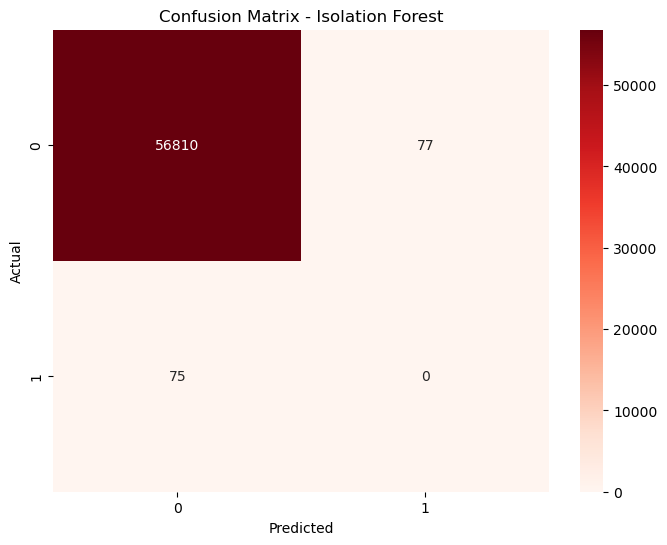

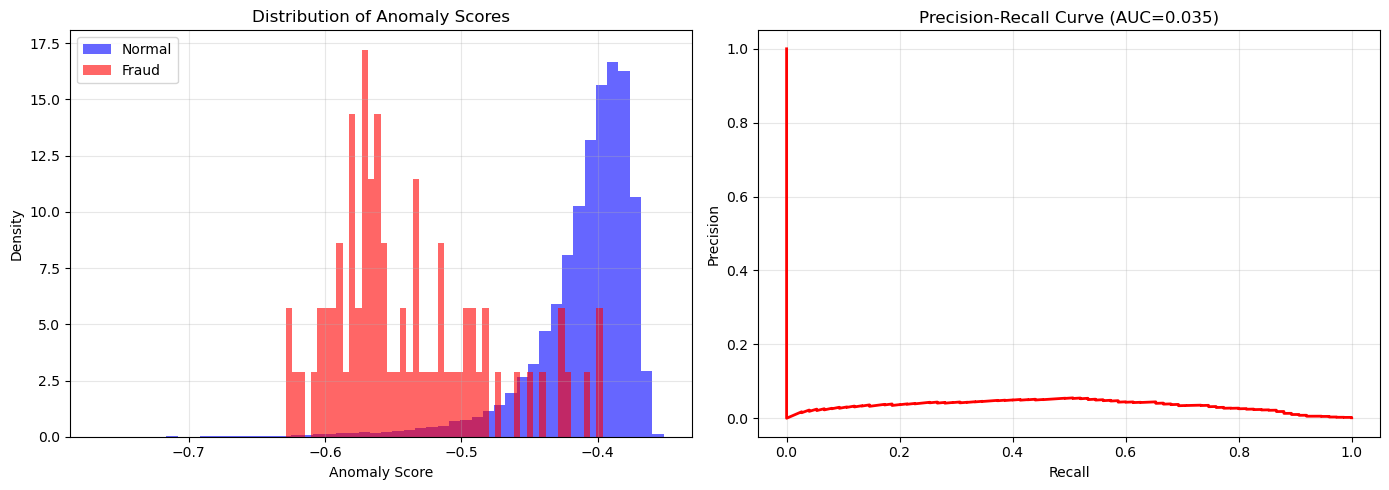

In [3]:
# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_iso_binary, 
                          target_names=['Normal', 'Fraud']))

# ROC-AUC and PR-AUC
roc_auc = roc_auc_score(y_test, y_pred_proba_iso)
pr_auc = average_precision_score(y_test, y_pred_proba_iso)

print(f"\nROC-AUC Score: {roc_auc:.4f}")
print(f"PR-AUC Score: {pr_auc:.4f}")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_iso_binary)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds')
plt.title('Confusion Matrix - Isolation Forest')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('../images/cm_isolation_forest.png', dpi=300, bbox_inches='tight')
plt.show()

# Plot anomaly score distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of anomaly scores
axes[0].hist(anomaly_scores[y_test == 0], bins=50, alpha=0.6, 
             label='Normal', color='blue', density=True)
axes[0].hist(anomaly_scores[y_test == 1], bins=50, alpha=0.6, 
             label='Fraud', color='red', density=True)
axes[0].set_xlabel('Anomaly Score')
axes[0].set_ylabel('Density')
axes[0].set_title('Distribution of Anomaly Scores')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Precision-Recall curve
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba_iso)
axes[1].plot(recall, precision, color='red', linewidth=2)
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title(f'Precision-Recall Curve (AUC={pr_auc:.3f})')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../images/isolation_forest_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

## Feature Importance via Anomaly Contribution


Top Features Contributing to Anomalies:
       feature  normal_mean  anomaly_mean  abs_diff
0           V1     0.282111     -1.902727  2.184838
28      Amount    -0.132778      1.534131  1.666909
2           V3    -0.556405     -1.673285  1.116880
7           V8     0.026406     -0.830924  0.857330
9          V10    -0.032847      0.779840  0.812686
19         V20    -0.103230      0.684268  0.787498
30  Log_Amount    -0.143116      0.586268  0.729384
3           V4    -0.179843      0.313979  0.493822
4           V5     0.256278     -0.227942  0.484220
5           V6    -0.135681      0.266907  0.402588
1           V2     0.059949     -0.323910  0.383859
20         V21     0.027582      0.364978  0.337396
16         V17    -0.102853      0.220291  0.323144
27         V28    -0.015832     -0.286274  0.270441
18         V19     0.057420     -0.202454  0.259874


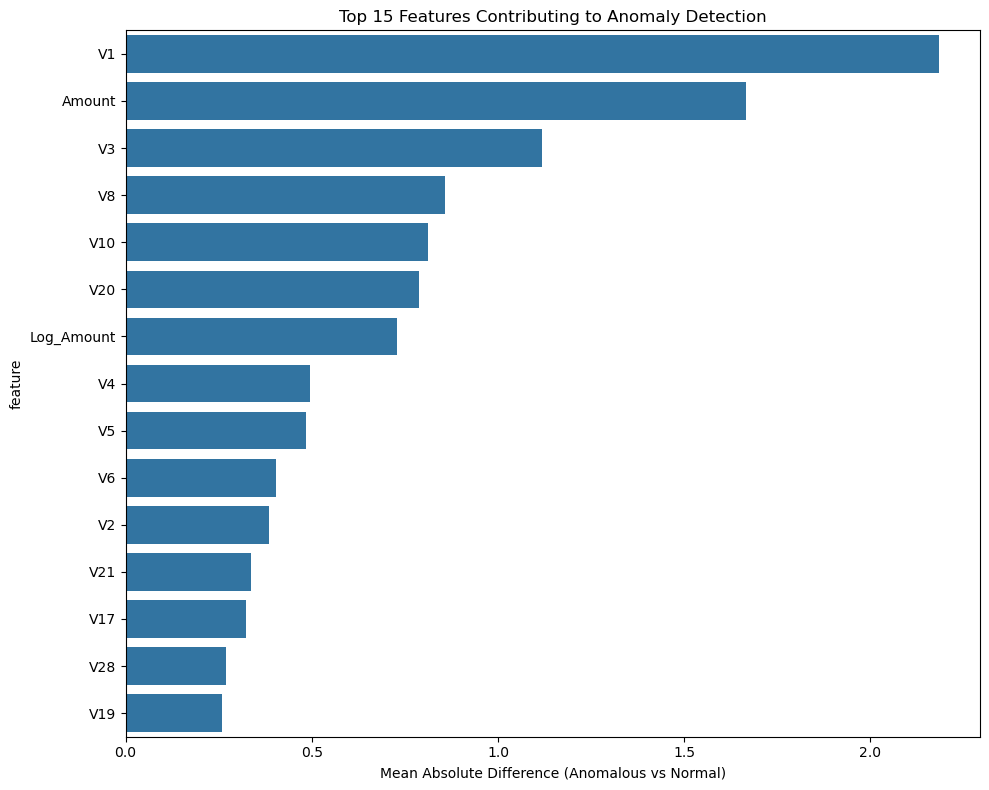

In [4]:
# Analyze which features contribute most to anomaly scores
def analyze_anomaly_features(X, anomaly_scores, feature_names, top_n=15):
    """Analyze feature contributions to anomalies"""
    
    # Get most anomalous samples
    anomaly_threshold = np.percentile(anomaly_scores, 5)  # Bottom 5%
    anomalous_mask = anomaly_scores < anomaly_threshold
    
    # Compare feature distributions
    feature_diffs = []
    for i, feature in enumerate(feature_names):
        normal_mean = X[~anomalous_mask, i].mean()
        anomaly_mean = X[anomalous_mask, i].mean()
        diff = abs(anomaly_mean - normal_mean)
        feature_diffs.append({
            'feature': feature,
            'normal_mean': normal_mean,
            'anomaly_mean': anomaly_mean,
            'abs_diff': diff
        })
    
    feature_df = pd.DataFrame(feature_diffs).sort_values('abs_diff', ascending=False)
    return feature_df

feature_importance = analyze_anomaly_features(
    X_test_scaled, anomaly_scores, feature_cols, top_n=15
)

print("\nTop Features Contributing to Anomalies:")
print(feature_importance.head(15))

# Visualize
plt.figure(figsize=(10, 8))
sns.barplot(data=feature_importance.head(15), y='feature', x='abs_diff')
plt.title('Top 15 Features Contributing to Anomaly Detection')
plt.xlabel('Mean Absolute Difference (Anomalous vs Normal)')
plt.tight_layout()
plt.savefig('../images/isolation_forest_features.png', dpi=300, bbox_inches='tight')
plt.show()